In [ ]:
# Hybrid Receiver Experiment: Combining classical DSP with deep learning.
# Instead of ground truth, this architecture is fed with the CFO and phase parameters
# estimated by the classical receiver, testing the neural demapper's robustness to estimation errors.

### 1. Imports

In [ ]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# Import simulation mechanics cleanly from our decoupled python file
from sionna_dg import (
    SimConfig,
    generate_dataset_offline,
    simulate_full_frames_tf,
    classical_receiver,
    build_sionna_blocks,
    estimate_phi_cfo_ml_grid
)

### 2. Globals, hyperparameters, devices

In [ ]:
torch.backends.cudnn.benchmark = True
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using Device: {DEVICE}")

# Configuration explicitly matched to the 152,088 parameter architecture
cfg_ofdm = SimConfig(
    num_examples=10000,
    bits_per_symbol=4,
    k=256,
    demap_method="app",
    dec_num_iter=15,
    cn_update="minsum",
    seed=46,
    channels_last=True,
    cfo_mode="direct",
    cfo_norm_min=-2e-4,
    cfo_norm_max=+2e-4,
    ebn0_db_min=0.0,
    ebn0_db_max=12.0,
    include_pilot_overhead_in_no=True,
    waveform="ofdm",
    ofdm_fft_size=64,
    ofdm_cp_len=16,
    ofdm_num_data_symbols=2,
    ofdm_num_pilot_symbols=1,
)

Using Device: cuda


### 3. Utils and helpers

In [ ]:
def set_seed_all(seed: int = 46):
    import random
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(int(seed))
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed_all(cfg_ofdm.seed)

### 4. Data loading

In [ ]:
def get_pytorch_ofdm_loaders(base_cfg, batch_size=128):
    print("Generating Specialized OFDM Dataset (80% in 4-8 dB range, 20% generalized)...")

    cfg_main = SimConfig(**{**base_cfg.__dict__, "num_examples": 8000, "ebn0_db_min": 4.0, "ebn0_db_max": 8.0})
    cfg_rand = SimConfig(**{**base_cfg.__dict__, "num_examples": 2000, "ebn0_db_min": 0.0, "ebn0_db_max": 12.0})

    ds_main = generate_dataset_offline(cfg_main)
    ds_rand = generate_dataset_offline(cfg_rand)

    x_rx = np.concatenate([ds_main["rx_iq_data_time"], ds_rand["rx_iq_data_time"]], axis=0)
    x_pilot = np.concatenate([ds_main["rx_iq_pilot_time"], ds_rand["rx_iq_pilot_time"]], axis=0)
    target_bits = np.concatenate([ds_main["coded_bits"], ds_rand["coded_bits"]], axis=0)

    tx_grid_main = ds_main["tx_grid"]
    tx_grid_rand = ds_rand["tx_grid"]
    n_pilot_sym = base_cfg.ofdm_num_pilot_symbols

    x_data_main = tx_grid_main[:, n_pilot_sym:, :, :].reshape(tx_grid_main.shape[0], -1, 2)
    x_data_rand = tx_grid_rand[:, n_pilot_sym:, :, :].reshape(tx_grid_rand.shape[0], -1, 2)
    x_data = np.concatenate([x_data_main, x_data_rand], axis=0)

    phi0 = np.concatenate([ds_main["phi0"], ds_rand["phi0"]], axis=0)
    cfo = np.concatenate([ds_main["cfo_norm"], ds_rand["cfo_norm"]], axis=0)

    x_rx_t = torch.tensor(x_rx).permute(0, 2, 1).float()
    x_pilot_t = torch.tensor(x_pilot).permute(0, 2, 1).float()
    target_bits_t = torch.tensor(target_bits).reshape(-1, base_cfg.seq_length, 4).permute(0, 2, 1).float()
    target_iq_t = torch.tensor(x_data).permute(0, 2, 1).float()

    phi0_t = torch.tensor(phi0).float().squeeze(-1)
    cfo_t = torch.tensor(cfo).float().squeeze(-1)

    dataset = TensorDataset(x_rx_t, x_pilot_t, phi0_t, cfo_t, target_bits_t, target_iq_t)

    train_size = int(0.85 * len(dataset))
    val_size = len(dataset) - train_size
    train_ds, val_ds = torch.utils.data.random_split(dataset, [train_size, val_size])

    return DataLoader(train_ds, batch_size=batch_size, shuffle=True), DataLoader(val_ds, batch_size=batch_size, shuffle=False)

### 5. Model definition and architecture

In [ ]:
# 5. Oracle Neural Receiver Architecture (Architecture Robustness Showcase)
class LinearAttention(nn.Module):
    def __init__(self, dim, heads=4):
        super().__init__()
        self.heads = heads
        self.dim_head = dim // heads
        self.scale = self.dim_head ** -0.5
        self.to_qkv = nn.Linear(dim, dim * 3, bias=False)
        self.to_out = nn.Linear(dim, dim)
        self.gamma = nn.Linear(dim, dim)
        self.beta = nn.Linear(dim, dim)

    def forward(self, x, latent_z):
        style_scale = self.gamma(latent_z).unsqueeze(1)
        style_shift = self.beta(latent_z).unsqueeze(1)
        x = x * (1 + style_scale) + style_shift
        b, n, d = x.shape
        qkv = self.to_qkv(x).chunk(3, dim=-1)
        q, k, v = map(lambda t: t.view(b, n, self.heads, self.dim_head).transpose(1, 2), qkv)
        q = q.softmax(dim=-1) * self.scale
        k = k.softmax(dim=-2)
        context = torch.matmul(k.transpose(-1, -2), v)
        out = torch.matmul(q, context)
        out = out.transpose(1, 2).reshape(b, n, d)
        return self.to_out(out)

class ResidualBlock1D(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.conv1 = nn.Conv1d(channels, channels, 3, padding=1)
        self.bn1 = nn.BatchNorm1d(channels)
        self.conv2 = nn.Conv1d(channels, channels, 3, padding=1)
        self.bn2 = nn.BatchNorm1d(channels)
        self.relu = nn.ReLU()
    def forward(self, x):
        return self.relu(x + self.bn2(self.conv2(self.relu(self.bn1(self.conv1(x))))))

class OracleNeuralReceiverOFDM(nn.Module):
    def __init__(self, ofdm_fft_size=64, ofdm_cp_len=16):
        super().__init__()
        self.fft_size = ofdm_fft_size
        self.cp_len = ofdm_cp_len

        self.latent_proj = nn.Sequential(nn.Linear(2, 32), nn.ReLU(), nn.Linear(32, 64), nn.Tanh())

        self.feat_extract = nn.Conv1d(2, 64, 7, padding=3)
        self.res1 = ResidualBlock1D(64)
        self.attn = LinearAttention(64)
        self.norm_attn = nn.LayerNorm(64)
        self.res2 = ResidualBlock1D(64)

        self.demap_mlp = nn.Sequential(
            nn.Conv1d(64, 32, 1), nn.ReLU(),
            nn.Conv1d(32, 16, 1), nn.ReLU(),
            nn.Conv1d(16, 4, 1)
        )

    def forward(self, x, gt_phi, gt_cfo):
        phi, cfo = gt_phi, gt_cfo

        z_input = torch.stack([torch.cos(phi), cfo * 1000.0], dim=1)
        z = self.latent_proj(z_input)

        B, _, L = x.shape
        t = torch.arange(L, device=x.device).float().unsqueeze(0)
        phase_ramp = phi.unsqueeze(1) + (cfo.unsqueeze(1) * t)
        cos_t, sin_t = torch.cos(-phase_ramp), torch.sin(-phase_ramp)
        r_I = x[:, 0, :] * cos_t - x[:, 1, :] * sin_t
        r_Q = x[:, 0, :] * sin_t + x[:, 1, :] * cos_t

        # OFDM Demodulation (FFT)
        x_comp = torch.complex(r_I, r_Q)
        n_sym = L // (self.fft_size + self.cp_len)
        x_sym = x_comp.reshape(B, n_sym, self.fft_size + self.cp_len)
        x_no_cp = x_sym[:, :, self.cp_len:]
        x_freq = torch.fft.fft(x_no_cp, norm="ortho", dim=-1)
        x_freq = torch.fft.fftshift(x_freq, dim=-1)
        x_freq_flat = x_freq.reshape(B, n_sym * self.fft_size)

        feat_in = torch.stack([x_freq_flat.real, x_freq_flat.imag], dim=1)

        # Linear Attention Processing
        feat = F.relu(self.feat_extract(feat_in))
        feat = self.res1(feat)
        feat_attn = feat.permute(0, 2, 1)
        feat_attn = self.attn(self.norm_attn(feat_attn), z)
        feat = feat + feat_attn.permute(0, 2, 1)
        feat = self.res2(feat)

        return self.demap_mlp(feat)

### 6. Model training and validation

In [ ]:
train_loader, val_loader = get_pytorch_ofdm_loaders(cfg_ofdm, batch_size=128)

L_time = cfg_ofdm.ofdm_num_data_symbols * (cfg_ofdm.ofdm_fft_size + cfg_ofdm.ofdm_cp_len)
P_time = cfg_ofdm.ofdm_num_pilot_symbols * (cfg_ofdm.ofdm_fft_size + cfg_ofdm.ofdm_cp_len)

model_ofdm = OracleNeuralReceiverOFDM(
    ofdm_fft_size=cfg_ofdm.ofdm_fft_size, ofdm_cp_len=cfg_ofdm.ofdm_cp_len
).to(DEVICE)

optimizer = optim.AdamW(model_ofdm.parameters(), lr=2e-3, weight_decay=1e-4)
EPOCHS = 20
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
criterion_bce = nn.BCEWithLogitsLoss()

print("\n--- Training Physics-Informed ML Model ---")
for epoch in range(EPOCHS):
    model_ofdm.train()
    metrics = {'loss':0, 'ber':0}

    for x, p, y_p, y_c, target_bits, target_iq in train_loader:
        x, y_p, y_c = x.to(DEVICE), y_p.to(DEVICE), y_c.to(DEVICE)
        target_bits = target_bits.to(DEVICE)

        optimizer.zero_grad()
        bit_logits = model_ofdm(x, y_p, y_c)

        loss = criterion_bce(bit_logits, target_bits)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_ofdm.parameters(), max_norm=1.0)
        optimizer.step()

        metrics['loss'] += loss.item()
        with torch.no_grad():
            pred_bits = (bit_logits > 0).float()
            metrics['ber'] += (pred_bits != target_bits).float().mean().item()

    scheduler.step()
    n_tr = len(train_loader)
    print(f"Ep {epoch+1:02d}/{EPOCHS} | Train Loss: {metrics['loss']/n_tr:.4f} | BER: {metrics['ber']/n_tr*100:.2f}%")

Generating Specialized OFDM Dataset (80% in 4-8 dB range, 20% generalized)...


W0000 00:00:1772630403.565972   19974 gpu_device.cc:2342] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...



--- Training Oracle Physics-Informed ML Model ---
Ep 01/20 | Train Loss: 0.4256 | BER: 20.59%
Ep 02/20 | Train Loss: 0.3262 | BER: 14.16%
Ep 03/20 | Train Loss: 0.3232 | BER: 14.05%
Ep 04/20 | Train Loss: 0.3184 | BER: 14.04%
Ep 05/20 | Train Loss: 0.3152 | BER: 13.99%
Ep 06/20 | Train Loss: 0.3141 | BER: 13.95%
Ep 07/20 | Train Loss: 0.3128 | BER: 13.91%
Ep 08/20 | Train Loss: 0.3124 | BER: 13.91%
Ep 09/20 | Train Loss: 0.3120 | BER: 13.91%
Ep 10/20 | Train Loss: 0.3112 | BER: 13.87%
Ep 11/20 | Train Loss: 0.3110 | BER: 13.87%
Ep 12/20 | Train Loss: 0.3106 | BER: 13.86%
Ep 13/20 | Train Loss: 0.3101 | BER: 13.85%
Ep 14/20 | Train Loss: 0.3097 | BER: 13.83%
Ep 15/20 | Train Loss: 0.3095 | BER: 13.82%
Ep 16/20 | Train Loss: 0.3093 | BER: 13.81%
Ep 17/20 | Train Loss: 0.3088 | BER: 13.79%
Ep 18/20 | Train Loss: 0.3091 | BER: 13.80%
Ep 19/20 | Train Loss: 0.3086 | BER: 13.78%
Ep 20/20 | Train Loss: 0.3087 | BER: 13.79%


### 7. Model evaluation and prints

In [ ]:
ebn0_range = range(0, 13, 1)
base_post_ber, ml_post_ber = [], []
base_bler, ml_bler = [], []

# Estimation bounds from sionna_dg logic
cfo_min = float(cfg_ofdm.cfo_norm_min)
cfo_max = float(cfg_ofdm.cfo_norm_max)

print("\n--- Evaluating Classical-Assisted Neural Receiver ---")
model_ofdm.eval()
with torch.no_grad():
    for ebno in ebn0_range:
        cfg_eval = SimConfig(**{**cfg_ofdm.__dict__, "num_examples": 2000, "ebn0_db_min": float(ebno), "ebn0_db_max": float(ebno)})

        # 1. Generate data for this SNR
        full_tf = simulate_full_frames_tf(cfg_eval)
        ds_eval = generate_dataset_offline(cfg_eval)

        # 2. Classical Baseline
        rx_base = classical_receiver(cfg_eval, full_tf)
        m_base = rx_base["metrics"]
        base_post_ber.append(m_base["ber_post_info"])
        base_bler.append(m_base["bler_post_info"])

        # 3. Classical-Assisted ML Path
        y_rx_tf = full_tf["y_rx"]
        x_pilot_tf = full_tf["x_pilot"]
        P = int(full_tf["meta"]["P"])
        y_pilot_tf = y_rx_tf[:, :P]

        # Use the classical ML-Grid estimator from sionna_dg
        phi_hat_tf, cfo_hat_tf, _ = estimate_phi_cfo_ml_grid(
            cfg_eval, y_pilot_tf, x_pilot_tf, cfo_min=cfo_min, cfo_max=cfo_max
        )

        # Convert estimates to PyTorch for the NN
        est_phi = torch.from_numpy(phi_hat_tf.numpy()).float().squeeze(-1).to(DEVICE)
        est_cfo = torch.from_numpy(cfo_hat_tf.numpy()).float().squeeze(-1).to(DEVICE)

        # Feed raw signal and CLASSICAL estimates to the NN Decoder
        x_rx_t = torch.tensor(ds_eval["rx_iq_data_time"]).permute(0, 2, 1).float().to(DEVICE)
        info_bits_np = ds_eval["info_bits"]

        bit_logits = model_ofdm(x_rx_t, est_phi, est_cfo)
        llr_ml_np = bit_logits.permute(0, 2, 1).reshape(bit_logits.size(0), -1).cpu().numpy()

        # LLR Calibration
        snr_lin = 10 ** (ebno / 10.0)
        scale = snr_lin / 4.0 if ebno > 6 else 1.0 + (ebno * 0.5)
        llr_tf = tf.convert_to_tensor(llr_ml_np * scale, dtype=tf.float32)

        info_tf = tf.convert_to_tensor(info_bits_np, dtype=tf.uint8)

        # LDPC Decoding
        _, _, _, _, decoder = build_sionna_blocks(cfg_eval)
        info_hat = tf.cast(decoder(llr_tf) > 0.5, tf.uint8)

        # Metric Collection
        ml_ber_v = float(tf.reduce_mean(tf.cast(info_hat != info_tf, tf.float32)).numpy())
        ml_bler_v = float(tf.reduce_mean(tf.cast(tf.reduce_any(info_hat != info_tf, axis=1), tf.float32)).numpy())

        ml_post_ber.append(ml_ber_v)
        ml_bler.append(ml_bler_v)
        print(f"Eb/N0={ebno:4.1f} dB | BASE postBER={m_base['ber_post_info']:.3e} | Hybrid ML postBER={ml_ber_v:.3e}")


--- Evaluating Classical-Assisted Neural Receiver ---
Eb/N0= 0.0 dB | BASE postBER=3.017e-01 | Hybrid ML postBER=3.047e-01
Eb/N0= 1.0 dB | BASE postBER=2.850e-01 | Hybrid ML postBER=2.854e-01
Eb/N0= 2.0 dB | BASE postBER=2.650e-01 | Hybrid ML postBER=2.676e-01
Eb/N0= 3.0 dB | BASE postBER=2.460e-01 | Hybrid ML postBER=2.473e-01
Eb/N0= 4.0 dB | BASE postBER=2.277e-01 | Hybrid ML postBER=2.260e-01
Eb/N0= 5.0 dB | BASE postBER=2.025e-01 | Hybrid ML postBER=2.024e-01
Eb/N0= 6.0 dB | BASE postBER=1.548e-01 | Hybrid ML postBER=1.554e-01
Eb/N0= 7.0 dB | BASE postBER=6.986e-02 | Hybrid ML postBER=6.464e-02
Eb/N0= 8.0 dB | BASE postBER=2.004e-02 | Hybrid ML postBER=1.716e-02
Eb/N0= 9.0 dB | BASE postBER=7.295e-03 | Hybrid ML postBER=4.719e-03
Eb/N0=10.0 dB | BASE postBER=2.225e-03 | Hybrid ML postBER=6.582e-04
Eb/N0=11.0 dB | BASE postBER=6.328e-04 | Hybrid ML postBER=4.883e-05
Eb/N0=12.0 dB | BASE postBER=2.207e-04 | Hybrid ML postBER=0.000e+00


### 8. Plots

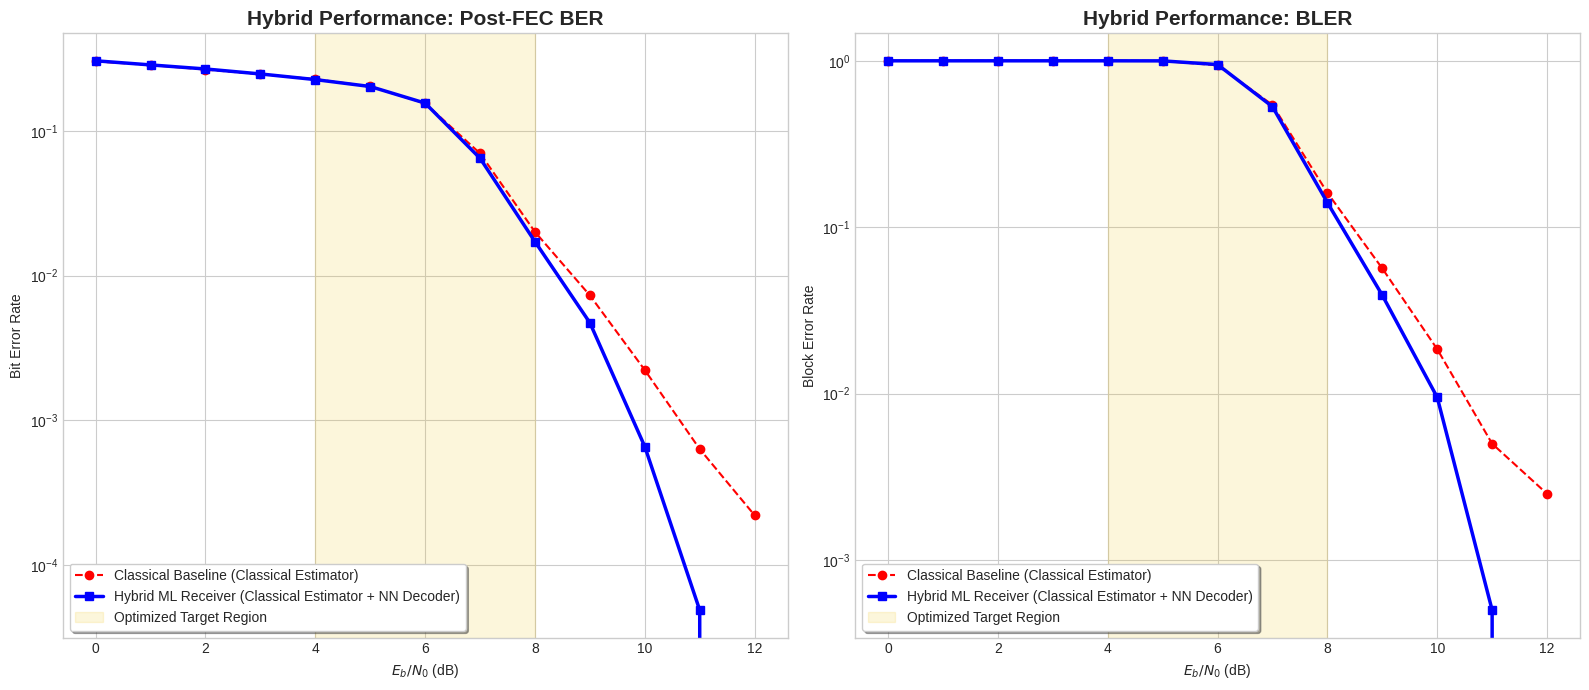

In [ ]:
plt.style.use('seaborn-v0_8-whitegrid')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Plot 1: BER
ax1.semilogy(ebn0_range, base_post_ber, 'r--o', label='Classical Baseline (Classical Estimator)')
ax1.semilogy(ebn0_range, ml_post_ber, 'b-s', linewidth=2.5, label='Hybrid ML Receiver (Classical Estimator + NN Decoder)')
ax1.axvspan(4, 8, color='#f1c40f', alpha=0.15, label='Optimized Target Region')
ax1.set_title("Hybrid Performance: Post-FEC BER", fontsize=15, fontweight='bold')
ax1.set_ylabel("Bit Error Rate"); ax1.set_xlabel("$E_b/N_0$ (dB)")
ax1.legend(frameon=True, shadow=True)

# Plot 2: BLER
ax2.semilogy(ebn0_range, base_bler, 'r--o', label='Classical Baseline (Classical Estimator)')
ax2.semilogy(ebn0_range, ml_bler, 'b-s', linewidth=2.5, label='Hybrid ML Receiver (Classical Estimator + NN Decoder)')
ax2.axvspan(4, 8, color='#f1c40f', alpha=0.15, label='Optimized Target Region')
ax2.set_title("Hybrid Performance: BLER", fontsize=15, fontweight='bold')
ax2.set_ylabel("Block Error Rate"); ax2.set_xlabel("$E_b/N_0$ (dB)")
ax2.legend(frameon=True, shadow=True)

plt.tight_layout(); plt.show()